# Objective

Build a machine learning model that classifies job postings as Real or Fraudulent by analyzing textual and structured job information. The goal is to help job seekers identify potentially fraudulent job advertisements.

## Objectives

* Understand the characteristics of fake job postings.
* Perform comprehensive data cleaning.
* Explore important trends through visualization.
* Apply NLP techniques to process textual information.
* Build and evaluate machine learning models.
* Provide actionable insights for identifying fraudulent job advertisements.

## Import Libraries

In [1]:
# Data Manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# NLP
import nltk
import re
import string

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")

## Load Dataset

In [3]:
import os

print(os.listdir('/kaggle/input'))

['datasets']


In [5]:
dataset_path = "/kaggle/input/datasets"

print(os.listdir(dataset_path))

['shivamb']


In [7]:
dataset_path = "/kaggle/input/datasets/shivamb"

print(os.listdir(dataset_path))

['real-or-fake-fake-jobposting-prediction']


In [8]:
dataset_path = "/kaggle/input/datasets/shivamb/real-or-fake-fake-jobposting-prediction"

print(os.listdir(dataset_path))

['fake_job_postings.csv']


In [10]:
df = pd.read_csv('/kaggle/input/datasets/shivamb/real-or-fake-fake-jobposting-prediction/fake_job_postings.csv')

## Dataset Overview

In [ ]:
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

In [11]:
df.head()

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


In [ ]:
df.sample(5, random_state=42)

In [12]:
print(df.shape)

(17880, 18)


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   job_id               17880 non-null  int64 
 1   title                17880 non-null  object
 2   location             17534 non-null  object
 3   department           6333 non-null   object
 4   salary_range         2868 non-null   object
 5   company_profile      14572 non-null  object
 6   description          17879 non-null  object
 7   requirements         15184 non-null  object
 8   benefits             10668 non-null  object
 9   telecommuting        17880 non-null  int64 
 10  has_company_logo     17880 non-null  int64 
 11  has_questions        17880 non-null  int64 
 12  employment_type      14409 non-null  object
 13  required_experience  10830 non-null  object
 14  required_education   9775 non-null   object
 15  industry             12977 non-null  object
 16  func

In [14]:
df.describe()

,job_id,telecommuting,has_company_logo,has_questions,fraudulent
count,17880.000000,17880.000000,17880.000000,17880.000000,17880.000000
mean,8940.500000,0.042897,0.795302,0.491723,0.048434
std,5161.655742,0.202631,0.403492,0.499945,0.214688
min,1.000000,0.000000,0.000000,0.000000,0.000000
25%,4470.750000,0.000000,1.000000,0.000000,0.000000
50%,8940.500000,0.000000,1.000000,0.000000,0.000000
75%,13410.250000,0.000000,1.000000,1.000000,0.000000
max,17880.000000,1.000000,1.000000,1.000000,1.000000


In [18]:
df.describe(include='object')

,title,location,department,salary_range,company_profile,description,requirements,benefits,employment_type,required_experience,required_education,industry,function
count,17880,17534,6333,2868,14572,17879,15184,10668,14409,10830,9775,12977,11425
unique,11231,3105,1337,874,1709,14801,11967,6204,5,7,13,131,37
top,English Teacher Abroad,"GB, LND, London",Sales,0-0,We help teachers get safe &amp; secure jobs ab...,"Play with kids, get paid for it Love travel? J...",University degree required. TEFL / TESOL / CEL...,See job description,Full-time,Mid-Senior level,Bachelor's Degree,Information Technology and Services,Information Technology
freq,311,718,551,142,726,379,410,726,11620,3809,5145,1734,1749


In [15]:
df.sample(5)

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
1799,1800,Partnerships/Business Development Intern,"SG, ,",Sales,NaN,If working in a cubical seems like your idea o...,We are looking for an Partnerships/Business De...,Excellent Business Level English. Positive out...,NaN,0,1,1,Full-time,Internship,NaN,Information Technology and Services,Sales,0
8764,8765,Graduates: English Teacher Abroad (Conversatio...,"US, MI, East Lansing",NaN,NaN,We help teachers get safe &amp; secure jobs ab...,"Play with kids, get paid for it Love travel? J...",University degree required. TEFL / TESOL / CEL...,See job description,0,1,1,Contract,Entry level,Bachelor's Degree,Education Management,Education,0
17264,17265,Front-End Developer/HTML/JavaScript/CSS,"US, CA, Greater Los Angeles Area",NaN,960000-1200000,"Replise was started in 2008, just a year after...","Our Company, Replise, a growing and exciting s...",Requirements:4+ years of coding using Javascr...,"About RepliseAt Replise, we believe in social ...",0,1,0,Full-time,NaN,NaN,Research,NaN,0
7559,7560,Customer Service Associate,"MU, PW, Ebene",Inbound Operations,NaN,HireEasy Pro provides specialised project recr...,"BackgroundOur customer, a leading multinationa...","LanguageFluent in English, French and Creole S...","Terms and BenefitsBase salary from Rs. 10,000 ...",0,1,1,NaN,NaN,NaN,NaN,NaN,0
11111,11112,Mirfield Warehousing Apprenticeship Under NAS ...,"GB, , Mirfield",NaN,NaN,Established on the principles that full time e...,Government funding is only available for 16-1...,16-18 year olds only due to government funding...,Career prospects.,0,1,1,Full-time,Not Applicable,High School or equivalent,Warehousing,NaN,0


In [17]:
df.dtypes

job_id                  int64
title                  object
location               object
department             object
salary_range           object
company_profile        object
description            object
requirements           object
benefits               object
telecommuting           int64
has_company_logo        int64
has_questions           int64
employment_type        object
required_experience    object
required_education     object
industry               object
function               object
fraudulent              int64
dtype: object

### Missing Values

In [ ]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum()/len(df)*100).round(2)
})

missing = missing.sort_values("Missing Values", ascending=False)

missing

In [19]:
duplicates = df.duplicated().sum()

print(f"Duplicate Rows: {duplicates}")

Duplicate Rows: 0


In [20]:
df = df.drop_duplicates()

## Target Variable Distribution

In [ ]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=missing.index,
    y=missing["Percentage"],
    palette="viridis"
)

plt.xticks(rotation=70)
plt.ylabel("Missing Percentage")
plt.title("Missing Values Percentage by Feature", fontsize=15)

plt.show()

In [ ]:
plt.figure(figsize=(6,5))

ax = sns.countplot(
    x="fraudulent",
    data=df,
    palette=["#4CAF50","#F44336"]
)

ax.bar_label(ax.containers[0])

plt.title("Real vs Fraudulent Job Postings")

plt.xlabel("Fraudulent")
plt.ylabel("Number of Jobs")

plt.show()

In [ ]:
fraud_percentage = (
    df['fraudulent']
      .value_counts(normalize=True)
      .mul(100)
      .round(2)
)

fraud_percentage

In [22]:
duplicates = df.duplicated().sum()

print(f"Duplicate Rows : {duplicates}")

fraudulent
0    17014
1      866
Name: count, dtype: int64

In [23]:
df['fraudulent'].value_counts(normalize=True)*100

fraudulent
0    95.1566
1     4.8434
Name: proportion, dtype: float64

## Missing Values Visualization

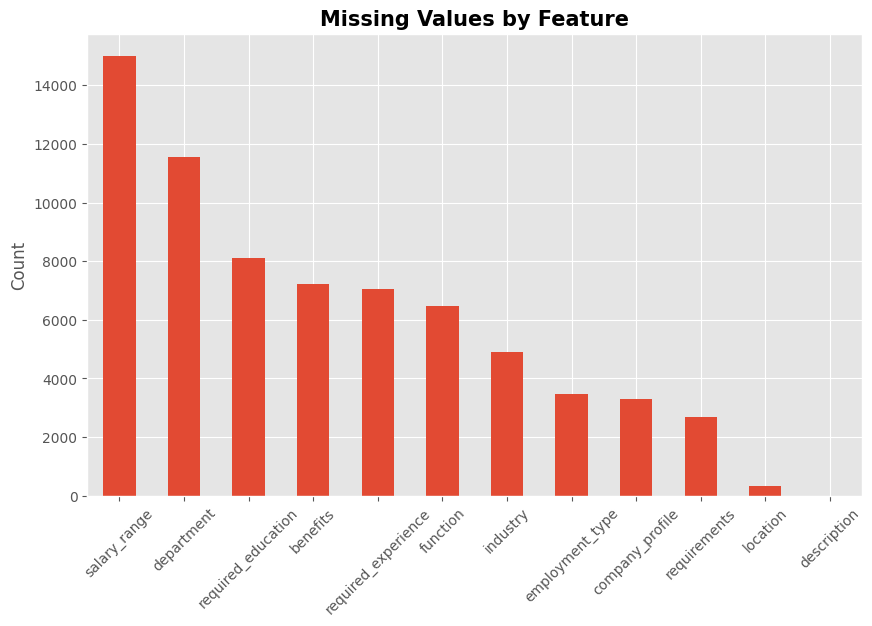

In [24]:
missing = df.isnull().sum().sort_values(ascending=False)

missing = missing[missing > 0]

plt.figure(figsize=(10,6))

missing.plot(kind='bar')

plt.title("Missing Values by Feature",
          fontsize=15,
          weight='bold')

plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

## Unique Values

In [ ]:
unique = pd.DataFrame({
    "Unique Values": df.nunique()
})

unique.sort_values("Unique Values", ascending=False)

# Understanding the Target

In [ ]:
# Count real and fake job postings
fraud_counts = df['fraudulent'].value_counts().sort_index()

plt.figure(figsize=(7,5))

ax = sns.barplot(
    x=['Real', 'Fake'],
    y=fraud_counts.values,
    palette=['#2ECC71', '#E74C3C']
)

# Add labels
for i, value in enumerate(fraud_counts.values):
    ax.text(i, value + 100, f'{value:,}', ha='center', fontsize=11)

plt.title("Distribution of Real vs Fake Job Postings", fontsize=15, weight='bold')
plt.ylabel("Number of Job Postings")
plt.xlabel("")

plt.show()